


















































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































































korean # Module 5: Programming Assignment

In [46]:
library(testthat)
library(ggplot2)
library(mvtnorm)

expect_constant = function(actual, tolerance = .Machine$double.eps^0.5) {
  if (length(actual) == 0) {
    fail("The vector is empty.")
  }
  
  # Check if all elements are the same within the given tolerance
  if (all(abs(actual - actual[1]) < tolerance)) {
    succeed()
  } else {
    fail("Your answer is not proportional to the posterior.")
  }
}

## Problem 1: Mixture simulations

Consider `x` in the cell below to be data. Let's suppose that a group of four researchers, none of which know the true mean `mu_true`, wish to estimate it with a Bayesian posterior. However, there is disagreement among the researchers' priors:

- Researcher #1: $\mu \sim N(3,1)$

- Researcher #2: $\mu \sim N(7,1)$

- Researcher #3: $\mu \sim N(10,1)$

- Researcher #4: $\mu \sim N(12,1)$

Further, Researcher #2 and Researcher #3 have more expertise about the data generating process, and so their prior beliefs should be given the highest weight. Researcher #1 is somewhat trusted, and Researcher #4 is inexperienced, and so we trust them relatively little. More precisely, we weight each researchers' prior according to `alpha = c(0.25, 0.4, 0.3, 0.05)`.

In [93]:
set.seed(5630)
n = 50; mu_true = 5; sig_true = 2; x = rnorm(n,mu_true,sig_true)
#x[1:8]  # the data
mean(x)
var(x)

[1] 4.691267

[1] 2.897017

**1 (a) [8 points] Construct a prior distribution as a mixture of each individual researcher's prior using $m = 100$ evenly spaced values of $\mu$ between 1 and 15, (i.e. use `seq(1,15,length.out = 100`)) to construct a grid of possible values for $\mu$ and store this grid as `mu_grid`.  Store the prior distribution in a variable labeled `mx_prior`.**    

Note that mixture distributions can be defined as:

Let $\theta_1,...,\theta_n$ be continuous random variables with pdfs $\pi_{i}(\theta)$, $i = 1,...,n$. Define a *mixture distribution* to be a random variable $\theta$ with pdf

\begin{align*}
\pi(\theta) = \sum^n_{i=1}\alpha_i \pi_{i}(\theta) 
\end{align*}

where $\alpha_i$ are nonnegative real numbers such that $\sum^n_{i=1}\alpha_i = 1$.


In [94]:
mu_grid = seq(1,15,length.out = 100) 
m = 100; # number of evenly spaced grid values
alpha = c(0.25, 0.4, 0.3, 0.05); #prior weights
mu0 = c(3,7,10,12) #mean of each researcher's prior (as given in the problem statement)
#mx_prior = dnorm(mu_grid, sum(alpha*mu0), 1)
#mx_prior = rowSums(sapply(mu0, function(mu) dnorm(mu_grid, mu, 1)) * alpha)
mx_prior = alpha[1] * dnorm(mu_grid, mu0[1], 1) +
           alpha[2] * dnorm(mu_grid, mu0[2], 1) +
           alpha[3] * dnorm(mu_grid, mu0[3], 1) +
           alpha[4] * dnorm(mu_grid, mu0[4], 1)
#length(mx_prior)
#mx_prior
#sum(alpha*mu0)
# your code here
#.NotYetImplemented()

**1 (b) [2 points] Using ggplot, plot the prior and store the plot in a variable labelled `p_prior`.**

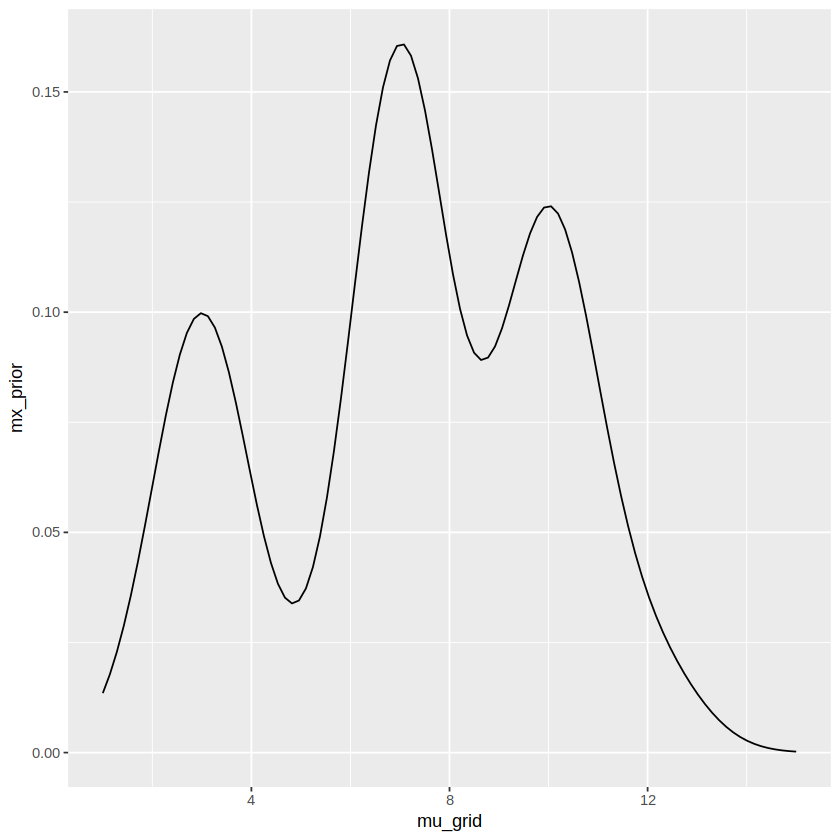

In [99]:
p_prior = ggplot(data.frame(mu_grid= mu_grid, prior=mx_prior)) + geom_line(aes(mu_grid, mx_prior)) 
 #geom_histogram(aes(mu_grid, mx_prior), stat='identity')
p_prior

# your code here
#.NotYetImplemented()

**1 (c) [5 points] Calculate the likelihood function given the data, `x`, for the grid of $\mu$ values stored in `mu_grid`.  Store the results in a vector labeled `mx_like`. Using ggplot, plot the likelihood function for the data and store the plot in a variable labelled `p_like`.** 

HINT: The likelihood function will be a product of marginal normal pdfs, interpreted as a function of the parameter $\mu$, with the data fixed. One could construct a loop where the $i^{th}$ iteration (after the first) is the product of what came before and the marginal pdf for a fixed $x_i$, at a given $\mu$. (What happens on the first iteration?)

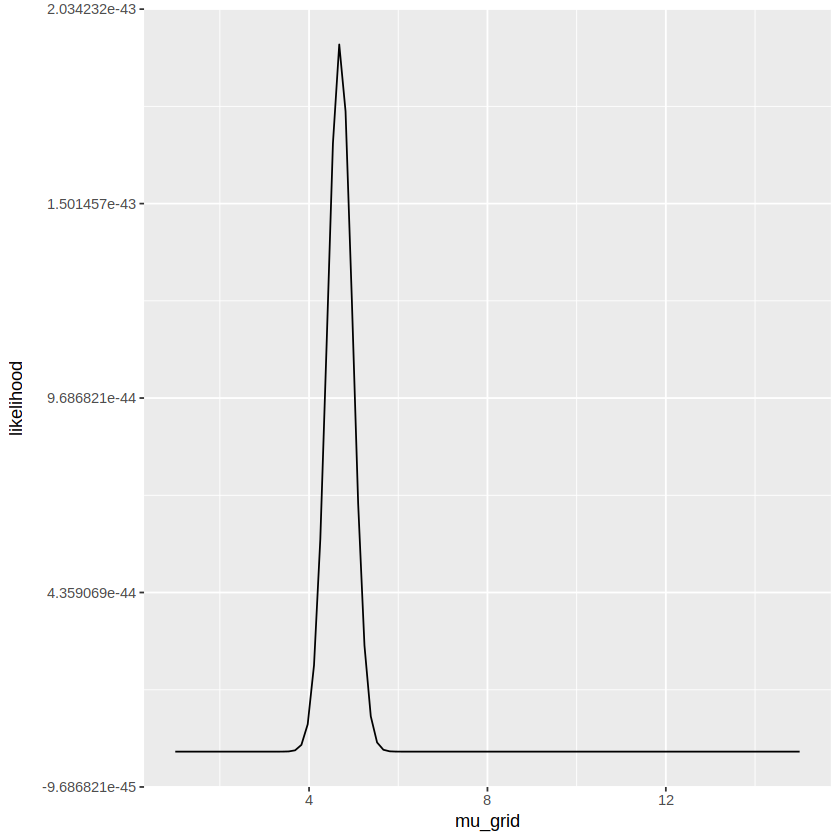

In [100]:
likelihood <- function(mu) {
    l = 1
    for (i in 1:n) {
        l = l * dnorm(x[i], mu, sig_true)
    }
    l  
}
#n = length(x)
mx_like = likelihood(mu_grid)
p_like = ggplot(data.frame(mu_grid=mu_grid, likelihood=mx_like)) + geom_line(aes(mu_grid, likelihood))
#geom_histogram(aes(mu_grid, likelihood), stat='identity')
p_like
#mu_grid[which.max(mx_like)]
#mean(x)
# your code here
#.NotYetImplemented()

**1 (d) [6 points] Calculate the posterior for the grid of $\mu$ values stored in `mu_grid`.  Store the results in a vector labeled `mx_post`. Using ggplot, plot the posterior and store the plot in a variable labelled `p_post`.**

HINT: For this problem, you'll make use of `m`, `alpha` and `mu0` from previous parts.

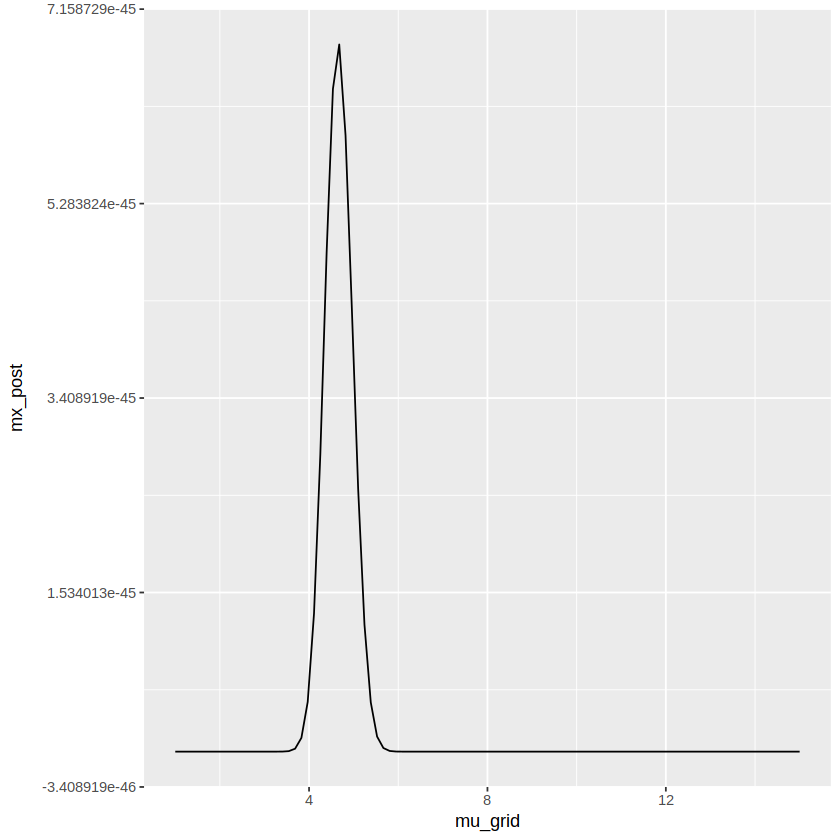

In [101]:
mx_post = mx_like * mx_prior
p_post = ggplot(data.frame(mu_grid=mu_grid, prior=mx_post)) + geom_line(aes(mu_grid, mx_post))
p_post

# your code here
#.NotYetImplemented()

**1 (e) [2 points] [Multiple Choice] What do you notice about the plot of the posterior?**
 
Select the best response to this question and storing the number associated with the response in a variable labelled `choice`.    
1. The posterior distribution has greatly reduced uncertainty and disagreement across researchers.
2. The posterior is identical to the likelihood function.  
3. The posterior is nearly identical to the mixture prior indicating that mixture priors have more influence that non-mixture priors.

For example, if you believe the best response is #3, code: `choice=1` in the code block below.

In [45]:
choice = 1

# your code here
#.NotYetImplemented()

## Problem 2: Bayesian linear regression

Consider data on the number of hours of exercise per week versus the risk of developing a disease. We will look at two sets of patients: those below the age of 50 and those over the age of 50.

**Explore the data graphically and numerically, looking for relationships between variables. Then respond to the muliple choice and true/false questions below regarding this exploration.**

In [103]:
df = read.table("simp.txt", header = TRUE, sep = "\t")
n = dim(df)[1]; #number of data points
df$p = df$p/100 #turns risk into a value between 0 and 1

#the next few lines creates a factor that is 1 if the individual is older than 50 and 0 otherwise.
x = ifelse(df$age > 50, 1,0)
#df = cbind(df,x)
dfu = df[x == 0,]
dfo = df[x == 1,]
df$fifty = as.factor(ifelse(df$age > 50, 1,0))

      ages           hours               p           fifty  
 Min.   :20.00   Min.   :-0.4344   Min.   :0.07764   0:103  
 1st Qu.:36.00   1st Qu.: 2.6493   1st Qu.:0.23956   1: 97  
 Median :50.00   Median : 4.1273   Median :0.32868          
 Mean   :51.48   Mean   : 4.2498   Mean   :0.33694          
 3rd Qu.:67.00   3rd Qu.: 5.7218   3rd Qu.:0.43225          
 Max.   :85.00   Max.   : 9.1519   Max.   :0.58640          

[1] 200

[1] 96

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


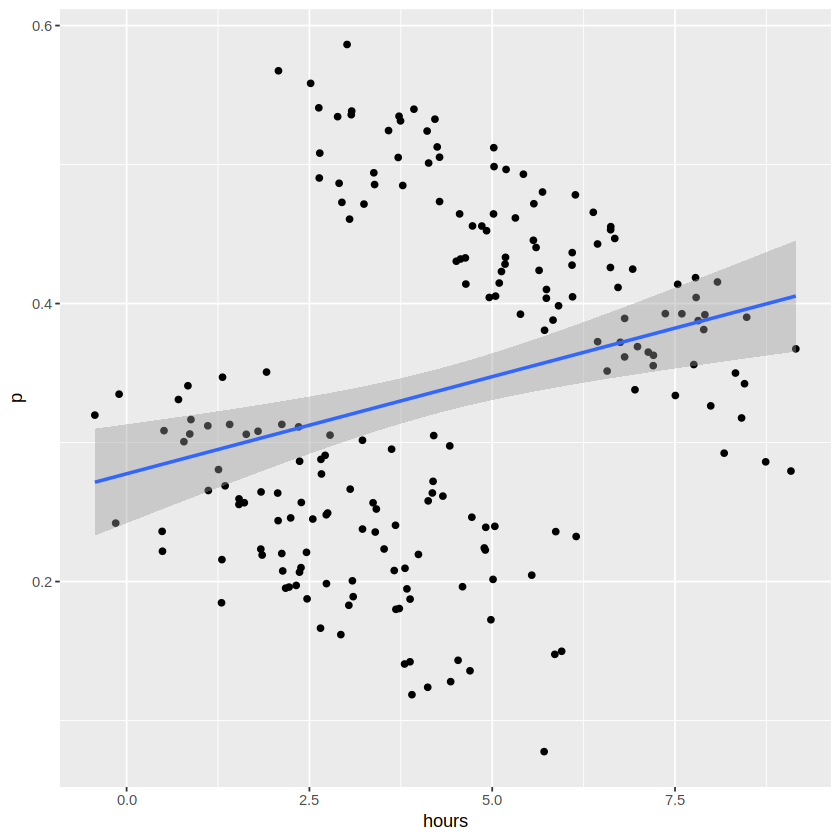

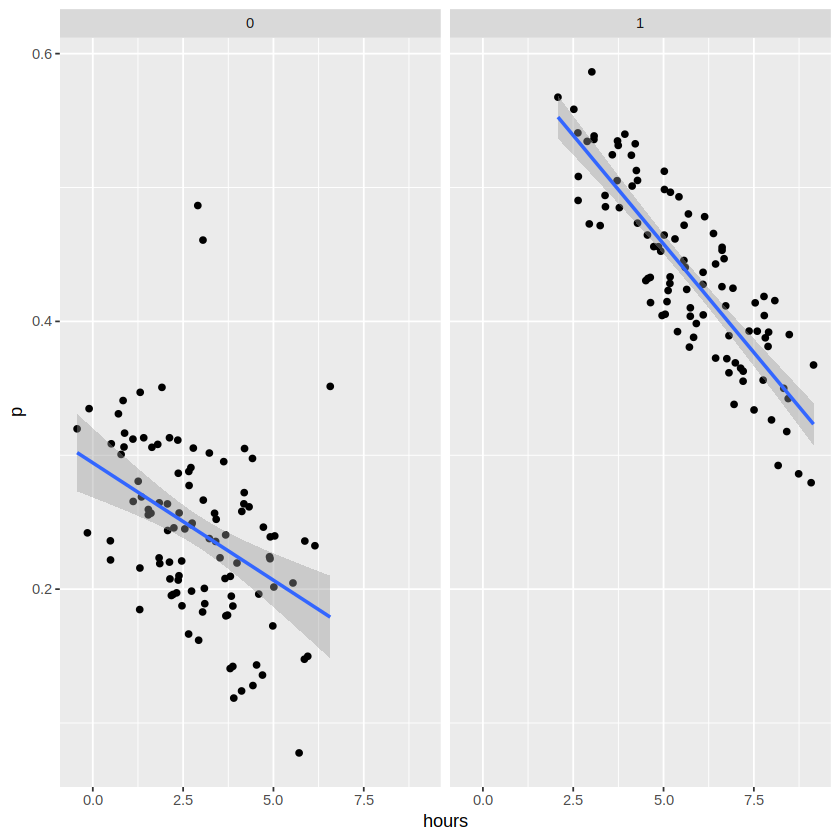

In [105]:
#There are no tests for this cell. Use it for explorations of the data related to the T/F questions below.
summary(df)
nrow(df)
nrow(df[df$ages < 50,])
ggplot(df, aes(hours, p)) +
  geom_point() +
  geom_smooth(method="lm")
ggplot(df, aes(hours, p)) +
  geom_point() +
  geom_smooth(method="lm") +
  facet_wrap(~ fifty)
# your code here
#.NotYetImplemented()

**2 (a) [2 point] [True or False] The mean of the variable `ages` is 51.48 and the median of the `hours` variable is roughly 4.1**

If you believe this statement is true, code `response=TRUE` into the code block below.  If you believe this statement to be false, code `response=FALSE` in the code block below.  Be sure to use all CAPS after the = sign.

In [ ]:
response = TRUE

# your code here
#.NotYetImplemented()

**2 (b) [2 point] [True or False] There are 97 individuals in the group under 50.**

If you believe this statement is true, code `response=TRUE` into the code block below.  If you believe this statement to be false, code `response=FALSE` in the code block below.  Be sure to use all CAPS after the = sign.

In [ ]:
response = FALSE

# your code here
#.NotYetImplemented()

**2 (c) [3 points] [Multiple Choice] What do you notice about the plot of the posterior?**
 
Select the best response to this question and storing the number associated with the response in a variable labelled `choice`.    
1. If group membership (groups are based on age) is taken into consideration, there is a positive relationship between `p` and `hours`. 
2. If group membership (groups are based on age) is NOT considered there is a positive relationship between `p` and `hours`.  
3. There's no relationship between `p` and `hours`..

For example, if you believe the best response is #3, code: `choice=1` in the code block below.

In [106]:
choice = 2

# your code here
#.NotYetImplemented()

Let's now fit a Bayesian linear regression model to estimate the relationship between `hours` and `p`:

\begin{align*}
p = \beta_0 + \beta_1\text{hours}_i + \varepsilon_i, \,\,\, \varepsilon_i \sim N(0,\sigma^2  = 0.1).
\end{align*}

For the prior distribution, assume that we are unsure about the value of the intercept ($\beta_0$) and slope ($\beta_1$) parameters, before observing the data. We also think that these parameters are uncorrelated. That is, our prior for $\beta_0$ and $\beta_1$ is multivariate normal with a variance covariance matrix that has "large" diagonal entries and zero for the off-diagonal entries. We will set the prior mean to the zero vector. Putting that all together, and quantifying "large": 

$$\left({\begin{array}{c} \beta_0 \\ \beta_1\\ \end{array}} \right) \sim N\left( \left( {\begin{array}{c}
   0  \\
   0  \\
  \end{array} } \right),   \left( {\begin{array}{cc}
   100 & 0 \\
   0 & 100 \\
  \end{array} } \right)\right).$$
With this normal prior, and normal error distribution ($\varepsilon_i \sim N(0,\sigma^2  = 0.1)$), we can use the normal-normal conjugate relationship, described in the videos for this course, to find the posterior distribution for $(\beta_0, \beta_1)^T$.

**2 (d) [10 points] Using the normal-normal conjugate relationship for a Bayesian regression model, compute the posterior mean and variance-covariance matrix for $(\beta_0, \beta_1)^T$. Store the mean of this posterior distribution in a vector labeled `mu_beta`. Store the variance-covariance matrix of this posterior distribution in a vector labeled `Sigma_beta`.**

Notes:

1. The posterior distribution mean and variance will use an $n \times 2$ "design matrix" $X$, with a first column of ones (associated with the intercept parameter) and a second column equal to the predictor measurements (the `hours` column in the dataframe). You will need to construct this matrix as part of the solution.


2. The `solve()` function can find the inverse of an invertible matrix (required in the formulas for the posterior mean and variance). 


3. the `t()` function computes the transpose of a matrix (required in the formulas for the posterior mean and variance).


In [69]:
predictors = 1 #number of predictors
mu0 = c(0,0); #prior mean for parameters
Sigma_p = diag(c(100,100),nrow = predictors+1, ncol = predictors+1); #prior variance/covariance matrix
sigma2 = 0.1
Sigma_n = sigma2*diag(1,nrow = n, ncol = n); #data variance-covariance matrix (remember n is the # of data points)

X = matrix(c(rep(1,n), df[,'hours']), nrow = n, ncol = 2); 
#X
y = df[,'p']
#y

#lm(y~X)

#Sigma_beta = matrix(NA, nrow = predictors+1, ncol = predictors+1);
#mu_beta = NA #variable for MAP of posterior regression parameters
Sigma_beta = solve(t(X) %*% solve(Sigma_n) %*% X + solve(Sigma_p))
mu_beta = Sigma_beta %*% (t(X) %*% solve(Sigma_n) %*% y + solve(Sigma_p) %*% mu0)
mu_beta
Sigma_beta
# your code here
#.NotYetImplemented()

0.27755148
0.01397315


0.0025004456,-0.0004707176
-0.0004707176,0.0001107627


**2 (e) [3 points] Construct a $95\%$ credible interval for the parameter associated with `hours` and store it in a vector labeled `CI_hours`.**

HINT: Since the posterior distribution of both parameters is multivariate normal, i.e., $\left({\begin{array}{c} \beta_0 \\ \beta_1\\ \end{array}} \right) \, | \, \text{data} \sim N\left( \left( {\begin{array}{c}
   \mu_1  \\
   \mu_2  \\
  \end{array} } \right),   \left( {\begin{array}{cc}
   \sigma_{11} & \sigma_{12} \\
   \sigma_{21} & \sigma_{22} \\
  \end{array} } \right)\right)$, the marginal distribution for both the slope and intercept are univariate normal: 

\begin{align*}
\beta_0 \, | \, \text{data} \sim N(\mu_{1}, \sigma_{11}) \\ 
\beta_1 \, | \, \text{data} \sim N(\mu_{2}, \sigma_{22}).
\end{align*}

The `qnorm()` quantile function can compute the credible intervals for these two marginal distributions.

In [70]:
CI_hours = c(qnorm((1-0.95)/2, mu_beta[2], sqrt(Sigma_beta[2,2])), qnorm(1-(1-0.95)/2, mu_beta[2], sqrt(Sigma_beta[2,2])))
CI_hours
# your code here
#.NotYetImplemented()

[1] -0.006654266  0.034600574

**2 (f) [5 points] Simulate $m = 1000$ values from the posterior predictive distribution for `p` at `hours_star = 4.25` using the following steps:**

1. Generate a random vector (of length 2) from the posterior distribution for the regression parameters, i.e., a multivariate normal distribution with mean `mu_beta` and variance-covariance matrix `Sigma_beta`. 


2. Use the random draw from the previous step, along with the variable `x_star` below (a vector that includes a intercept multiplier term and `hours_star = 4.25`), to generate a prediction from the likelihood function.


3. Repeat the steps above $m = 1000$ times. For $i = 1,...,m$, store the $i^{th}$ iteration of step 1 in the $i^{th}$ row of the $m \times 2$ matrix `beta_star`. Store the $i^{th}$ iteration of step 2 in the $i^{th}$ entry of the vector `y_star`.


4. Finally, calculate the mean of the posterior predictive distribution and store it in a variable labeled `pred_mean`.

HINTS: In step 2, the likelihood function will be normal, centered at $\beta_0^* + \beta_1^* \, \text{hours}^*$, where $\beta_0^*$ and $\beta_1^*$ are the $i^{th}$ draws of the intercept and slope from step 1, $\text{hours}^*$ is `hours_star = 4.25`, and $\sigma^2 = 0.1$. 

In [13]:
hours_star = 4.25
x_star = data.frame(cbind(1,hours_star)); 
names(x_star) = c("intercept", "hours");
x_star

intercept,hours
<dbl>,<dbl>
1,4.25


In [18]:
set.seed(1899)
m = 1000 #number of simulations
y_star = matrix(NA, nrow = m, ncol = 1) # vector for posterior predictive distribution draws
for (i in 1:m) {
    beta_star = rmvnorm(1, mean=mu_beta, sigma=Sigma_beta) #matrix for posterior distribution draws
    y_star[i] <- rnorm(1, sum(beta_star*x_star), sqrt(0.1))
}

pred_mean = mean(y_star)
pred_mean

#m <- lm(p ~ hours, df)
#predict(m, x_star)

# your code here
#.NotYetImplemented()

[1] 0.3304829

**2 (g) [3 points] Calculate the $95\%$ credible interval from the posterior predictive distribution simulations in the previous question, and store it in a vector labeled `pred_CI`.**

HINT: In this case, beucase we have simulations from a true posterior predictive distribution, and not the exact distribution itself, use the `quantile()` function rather than `qnorm()`. 

In [19]:
pred_CI = quantile(y_star, c(0.025, 0.975))
pred_CI

# your code here
#.NotYetImplemented()

2.5%      97.5% 
-0.2953473  0.9613726

**2 (h) [4 points] Now fit a Bayesian regression model, as above, but with `p` as the repsonse and two predictors: `hours` and `fifty`. Store the mean of the posterior distribution for the regression parameters (given the data) in a vector labelled `mu_2`. This vector should have length three and contain the mean of the posterior distribution for the intercept and parameters associated with `hours` and `fifty`, respectively.**

Notes:

- For your prior, assume, as in the one-predictor case, that you are pretty unsure about the value of the intercept and slope parameters, before observing the data. You also think that these parameters are uncorrelated.

- For the variance-covariance matrix of the data, $\Sigma_n$, assume that each response measurement ($p$) is uncorrelated with each other. Further, assume that each response has constant variance equal to $\sigma^2 = 0.002$.

- You'll need to construct a new $n \times 3$ design matrix, with a column of ones, a column with `hours`, and a column for `fifty`.



In [107]:
predictors2 = 2 #number of predictors
mu0 = c(0,0,0); #prior mean
Sigma_p = diag(c(100,100,100),nrow = predictors2+1, ncol = predictors2+1); #prior variance-covariance
n = dim(df)[1]; 

fifty = ifelse(df$ages > 50, 1, 0)
X = matrix(c(rep(1,n), df$hours, fifty), nrow = n, ncol = 3); 
#X
y = df[,'p']
#y

#dim(X)
#length(y)

#lm(y~X+0)

sig2 = 0.002 #constant variance for response data
Sigma_n = sig2*diag(1,ncol = n, nrow = n); #variance-covariance for the data/likelihood

#Sigma_beta = matrix(NA, nrow = predictors+1, ncol = predictors+1);
#mu_beta = NA #variable for MAP of posterior regression parameters
Sigma_beta = solve(t(X) %*% solve(Sigma_n) %*% X + solve(Sigma_p))
mu_2 = Sigma_beta %*% (t(X) %*% solve(Sigma_n) %*% y + solve(Sigma_p) %*% mu0)
mu_2
Sigma_beta
# your code here
#.NotYetImplemented()

0.31844224
-0.02576607
0.26390630


5.163809e-05,-1.099687e-05,1.050815e-05
-1.099687e-05,3.753221e-06,-1.021359e-05
1.050815e-05,-1.021359e-05,6.783009e-05


**2 (i) [3 points] [Multiple Choice] Compare the parameter estimate associated with `hours` in 2 (d) with the estimate associated with `hours` in 2 (h). Do these values seem inconsistent or in tension with each other?**

Select the best response to this question and storing the number associated with the response in a variable labelled `choice`.    
1. The two estimates are really close to 0, so they are not really inconsistent with one another. 
2. The apparent inconsistency here is that, in one regression, the aggregate effect of exercise is positive, and in the other regression, each marginal effect of exercise is negative. "Exercise is bad for everyone, but good for people under 50 and good for people over 50"!  
3. The results highlight the need to add the parameter estimate associated with `hours` from each model together to best estimate the true value of the regression coefficient for the `hours` feature.

For example, if you believe the best response is #3, code: `choice=3` in the code block below.

In [ ]:
choice = 2

# your code here
#.NotYetImplemented()